# Random Forest (Classification & Regression)

## Table of Contents
1. [Introduction](#1-introduction)
2. [Theory & Mathematics](#2-theory--mathematics)
3. [Assumptions & Requirements](#3-assumptions--requirements)
4. [When to Use This Algorithm](#4-when-to-use-this-algorithm)
5. [Implementation from Scratch (NumPy)](#5-implementation-from-scratch-numpy)
6. [Implementation with Scikit-learn](#6-implementation-with-scikit-learn)
7. [Hyperparameter Tuning](#7-hyperparameter-tuning)
8. [Complete Hyperparameter Reference](#8-complete-hyperparameter-reference)
9. [Practical Tips & Common Pitfalls](#9-practical-tips--common-pitfalls)
10. [Real-world Examples](#10-real-world-examples)
11. [Comparison with Other Algorithms](#11-comparison-with-other-algorithms)
12. [References](#12-references)


---

## 1. Introduction

### What is a Random Forest?

A Random Forest is an **ensemble of decorrelated decision trees** that votes (classification) or averages (regression) over its members. It combines two ideas - **bagging** (random bootstrap samples of the rows) and **random feature subsampling** (random candidate features at every node) - so that hundreds of individually-weak, unstable trees add up to one strong, stable model.

**Key characteristics:**
- **Supervised learning** algorithm for both classification and regression
- **Ensemble method** - hundreds of trees, not one
- **Bagging** - each tree sees a bootstrap sample (~63% unique rows)
- **Random subspace** - each node only considers a random subset of features
- **Self-validating** - out-of-bag (OOB) rows give a free test-like score
- **Robust defaults** - famously good accuracy with almost no tuning

**Historical Context:**
- Ho, T. K. (1995) - "Random Decision Forests" (random subspace method)
- Breiman, L. (1996) - "Bagging Predictors" (bootstrap aggregation)
- Amit & Geman (1997) - randomized trees for shape recognition
- Breiman, L. (2001) - "Random Forests" - unified the ideas; the name stuck

**Main Use Cases:**
- **Classification**: credit risk, churn prediction, fraud detection, medical risk
- **Regression**: house prices, demand forecasting, equipment failure
- Feature importance analysis
- The default "serious baseline" for tabular data before trying boosters

**How it works (simplified):**
1. Draw B bootstrap samples from the training data
2. Grow a decision tree on each sample - but at every node, only a random
   subset of features may be used for the split
3. Grow trees deep (unlike a single tree, overfitting is averaged away)
4. **Classification**: majority vote across trees
5. **Regression**: average across trees
6. Use OOB samples to estimate generalization error for free


In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


Libraries imported successfully!
NumPy version: 2.5.1
Pandas version: 3.0.3


---

## 2. Theory & Mathematics

### Core Concept: Bagging + Random Feature Subsampling

A Random Forest is an ensemble of $B$ decision trees, each trained on a **bootstrap sample** of the rows, each restricted at every node to a **random subset of features**. The trees are deliberately made different from each other - and that difference is what makes the average strong.

#### The Two Sources of Randomness

**1. Bagging (Bootstrap AGgregating)**

Each tree trains on $n$ samples drawn **with replacement**. The probability a given row is never drawn:

$$P(\text{row } i \text{ left out}) = \left(1 - \frac{1}{n}\right)^n \xrightarrow{n \to \infty} e^{-1} \approx 0.368$$

So each bootstrap sample contains ~**63.2% unique rows**, and the remaining ~**36.8% (out-of-bag, OOB)** are never seen by that tree - a free validation set.

**2. Random Feature Subsampling**

At every node, only `max_features` candidate features are considered ($\sqrt{m}$ by default for classification). Without this, bootstrapped trees would still be highly correlated: the same dominant feature wins every root node, the trees make the *same mistakes*, and averaging buys almost nothing.

### Why Averaging Reduces Variance

For $B$ identically distributed tree predictions with pairwise correlation $\rho$ and per-tree variance $\sigma^2$ (Breiman 2001; ESL §15.2):

$$\text{Var}(\bar{f}) = \rho\sigma^2 + \frac{1-\rho}{B}\,\sigma^2$$

- The second term shrinks to 0 as $B$ grows: **more trees never hurt accuracy**
- The first term survives: the **correlation floor** $\rho\sigma^2$ is the irreducible part
- Random feature subsampling lowers $\rho$ - this is what separates Random Forests from plain bagging

### Aggregation Rules

**Classification** - majority vote:

$$\hat{y} = \text{mode}\{h_1(x), h_2(x), \ldots, h_B(x)\}$$

Probability estimate: the fraction of trees voting for each class.

**Regression** - average:

$$\hat{y} = \frac{1}{B}\sum_{b=1}^{B} h_b(x)$$

### Out-of-Bag (OOB) Error

For each training row, aggregate predictions **only from trees that did not train on it** (~36.8% of trees per row):

1. For tree $b$, predict only its OOB rows
2. Aggregate per row (vote / average)
3. Score those OOB predictions against true labels

Result: a cross-validation-grade performance estimate **for free**, computed during training, without touching a test set.

### Feature Importance (Mean Decrease in Impurity, MDI)

For each feature, accumulate the impurity decrease of every split that used it, weighted by the samples reaching that node; normalize per tree, average over trees:

$$\text{Imp}(f) = \frac{1}{B}\sum_{b=1}^{B}\;\frac{1}{Z_b}\sum_{\text{splits } t \text{ on } f} \frac{n_t}{n}\,\Delta\, i(t)$$

⚠️ MDI is **biased toward continuous / high-cardinality features** - for honest rankings, use `permutation_importance`.

### Computational Complexity

- **Training**: $O(B \times \text{single-tree cost})$ - trees are independent, so training **parallelizes perfectly** (`n_jobs=-1`)
- **Prediction**: $O(B \times \text{depth})$ - every tree must be traversed
- **Memory**: $O(B \times \text{nodes})$ - the forest is $B$ full trees (much heavier than one)


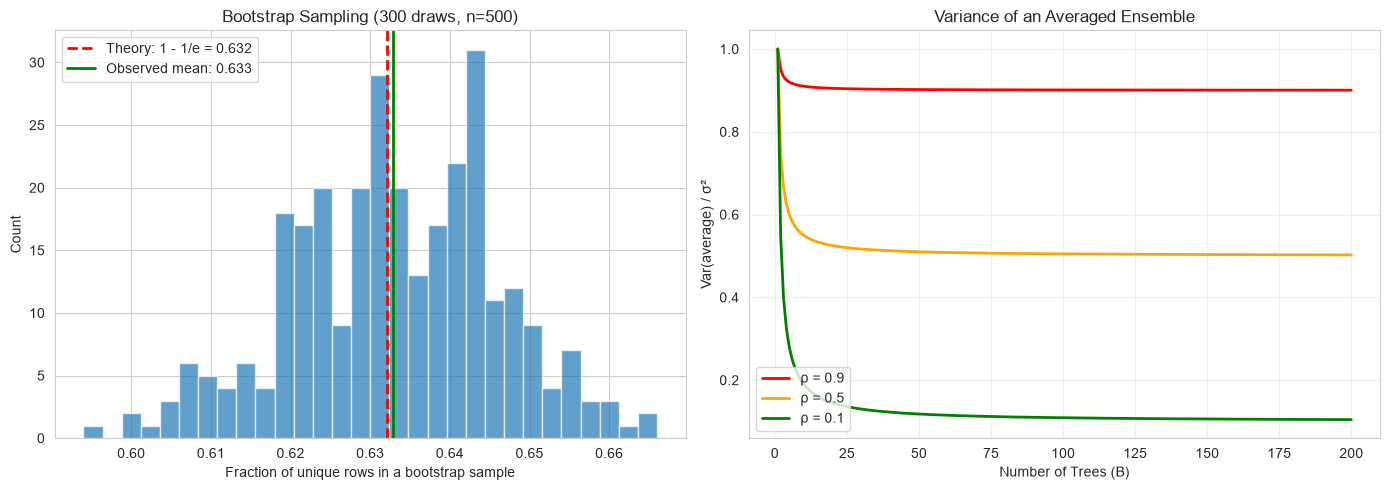

🌲 Bootstrap math:
  • Unique rows in a bootstrap sample: 63.3% (theory: 63.2%)
  • Out-of-bag rows per tree:          36.7% (theory: 36.8%)

💡 The variance story:
  • More trees (B↑): variance falls as (1-ρ)/B → 0 - adding trees never hurts
  • The floor is ρσ²: correlated trees keep making the same mistakes
  • Random feature subsampling lowers ρ - the second randomization that makes RF work


In [2]:
# Visualize the two sources of randomness
np.random.seed(42)

n_samples = 500
n_trials = 300

# --- Panel 1: bootstrap sampling behavior ---
unique_fracs = []
for _ in range(n_trials):
    indices = np.random.randint(0, n_samples, size=n_samples)
    unique_fracs.append(len(np.unique(indices)) / n_samples)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(unique_fracs, bins=30, color='#1f77b4', alpha=0.7, edgecolor='white')
axes[0].axvline(x=1 - np.exp(-1), color='red', linestyle='--', linewidth=2,
                label=f'Theory: 1 - 1/e = {1 - np.exp(-1):.3f}')
axes[0].axvline(x=np.mean(unique_fracs), color='green', linewidth=2,
                label=f'Observed mean: {np.mean(unique_fracs):.3f}')
axes[0].set_xlabel('Fraction of unique rows in a bootstrap sample')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Bootstrap Sampling ({n_trials} draws, n={n_samples})')
axes[0].legend()

# --- Panel 2: variance of the averaged ensemble ---
B = np.arange(1, 201)
for rho, color in zip([0.9, 0.5, 0.1], ['red', 'orange', 'green']):
    var_ratio = rho + (1 - rho) / B
    axes[1].plot(B, var_ratio, color=color, linewidth=2, label=f'ρ = {rho}')
axes[1].set_xlabel('Number of Trees (B)')
axes[1].set_ylabel('Var(average) / σ²')
axes[1].set_title('Variance of an Averaged Ensemble')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

mean_unique = np.mean(unique_fracs)
print("🌲 Bootstrap math:")
print(f"  • Unique rows in a bootstrap sample: {mean_unique:.1%} (theory: 63.2%)")
print(f"  • Out-of-bag rows per tree:          {1 - mean_unique:.1%} (theory: 36.8%)")
print("\n💡 The variance story:")
print("  • More trees (B↑): variance falls as (1-ρ)/B → 0 - adding trees never hurts")
print("  • The floor is ρσ²: correlated trees keep making the same mistakes")
print("  • Random feature subsampling lowers ρ - the second randomization that makes RF work")


---

## 3. Assumptions & Requirements

### Minimal Assumptions (Inherited from Trees, Damped by Averaging)

✅ **No assumptions about:**
- Feature distributions
- Linear relationships
- Homoscedasticity
- Feature scaling (trees are scale-invariant)
- Outliers (splits use only feature order; averaging dampens their effect)

### What a Random Forest DOES Require:

1. **Labeled Data** (supervised learning)
   - Ensembling cannot create signal from nothing

2. **Enough Samples for Bootstrap Diversity**
   - Each tree sees ~63% of rows; on tiny datasets the trees become too similar
   - Rule of thumb: at least a few hundred rows for forests to shine

3. **Informative Features Somewhere in the Set**
   - With `max_features='sqrt'` a node sees only a random subset - signal must eventually surface
   - Many noise features dilute splits but rarely destroy the forest

4. **Train/Test from the Same Distribution**
   - Trees cannot extrapolate; forests inherit that limitation

### Feature Requirements

#### ✅ What Works Well:
- **Numerical features** (any scale - no standardization!)
- **Categorical features** (after encoding)
- **Non-linear relationships and interactions** (captured by individual trees, stabilized by averaging)
- **Redundant/correlated features** (tolerated; importances get shared between them)

#### ⚠️ What Needs Care:
- **Extrapolation** (predictions clamp to the training range, like any tree)
- **High-cardinality categorical features** (importance bias toward them)
- **Very high-dimensional sparse data** (e.g., bag-of-words) - linear models usually win
- **Small datasets (<100 rows)** - bootstraps too similar, forest ≈ single tree

### Key Differences from Single Trees

| Aspect | Single Decision Tree | Random Forest |
|--------|---------------------|---------------|
| **Variance** | High (unstable) | Low (averaged) |
| **Overfitting** | Almost certain if deep | Strongly damped |
| **Interpretability** | ⭐⭐⭐⭐⭐ (draw the tree) | ⭐⭐ (importances only) |
| **Tuning burden** | High (must prune) | Low (defaults are decent) |
| **Training cost** | 1 tree | B trees (parallelizable) |
| **OOB validation** | ❌ | ✅ built in |


---

## 4. When to Use This Algorithm

### ✅ Use Random Forest When:

1. **You need a strong default model on tabular data**
   - Excellent accuracy with near-zero tuning
   - The natural "first serious model" after a simple baseline

2. **Non-linear relationships and interactions exist**
   - Trees capture them natively; averaging stabilizes them

3. **Robustness matters**
   - Insensitive to outliers, noise, and feature scales
   - Handles redundant features gracefully

4. **You want feature importance signals**
   - MDI importances built in; permutation importances supported

5. **Medium to large tabular problems**
   - Hundreds to millions of rows; trees train in parallel across cores

6. **You need honest validation cheaply**
   - OOB score ≈ cross-validation, at zero extra cost

7. **Stable insights matter**
   - Importances and predictions are far more stable than a single tree's

### ❌ Avoid Random Forest When:

1. **Extrapolation is required**
   - Forecasting beyond the training range (time trends, growth curves)
   - Use linear models instead

2. **Full interpretability is required**
   - Regulated decisions may need an inspectable rule set
   - Use a single pruned tree or a linear scorecard

3. **Very high-dimensional sparse data**
   - Random feature subsampling over sparse text features is wasteful
   - Linear models usually dominate here

4. **Extreme latency or memory budgets**
   - Prediction traverses B trees; the model is B full trees
   - Consider boosting with fewer, smaller trees, or model distillation

5. **Streaming / online learning**
   - New data means growing or refitting trees; not incremental-friendly

6. **Tiny datasets**
   - A tuned single tree or linear model is often as good - and simpler

### Classification vs Regression

| Task Type | When to Use Random Forest |
|-----------|---------------------------|
| **Classification** | ✅ Multi-class problems<br>✅ Non-linear decision boundaries<br>✅ Feature importance analysis<br>✅ Imbalanced classes (with class_weight) |
| **Regression** | ✅ Non-linear relationships<br>✅ Feature interactions<br>⚠️ Smoothness needed (steps get averaged away)<br>❌ Extrapolation required |

### Random Forest vs Other Algorithms

**vs Single Decision Tree:**
- RF: Lower variance, better generalization, OOB validation; less interpretable
- Tree: Interpretable and fast, but unstable - risky alone in production

**vs Gradient Boosting (notebook 08):**
- RF: Trains trees in parallel; robust defaults; hard to overfit by accident
- Boosting: Often more accurate, but sequential and needs careful tuning

**vs Linear Models:**
- RF: Non-linear, no scaling, interactions for free
- Linear: Extrapolates, interpretable coefficients, better on sparse data

**vs KNN (notebook 07):**
- RF: Fast prediction, compact model, handles high dimensions better
- KNN: Zero training time, but slow prediction and scaling-sensitive


---

## 5. Implementation from Scratch (NumPy)

Our forest lives in `src/models/ensemble_models.py` and is built **on top of the scratch decision trees** from notebook 03 - which is exactly how a random forest should be understood: a randomized *harness* around ordinary trees.

What the harness adds:

1. **Bootstrap sampling** - each tree trains on ~63% unique rows drawn with replacement
2. **Per-node feature subsampling** - the base trees search all features at a node; a small subclass restricts every node's search to `max_features` random columns (Breiman's core trick)
3. **Aggregation** - majority vote (classification) or mean (regression)
4. **OOB estimation** - per-tree out-of-bag masks are tracked to compute a free validation score
5. **Feature importances** - each split's impurity decrease is recorded and aggregated across the forest


In [3]:
# Import our from-scratch implementations
import sys
sys.path.append('../src')

from models.ensemble_models import RandomForestClassifierScratch, RandomForestRegressorScratch

print("✅ Imported custom Random Forest implementations!")
print("\nAvailable classes:")
print("  • RandomForestClassifierScratch")
print("  • RandomForestRegressorScratch")
print("\nBoth reuse the scratch decision trees as base learners")
print("and add bootstrap sampling + per-node feature subsampling.")


✅ Imported custom Random Forest implementations!

Available classes:
  • RandomForestClassifierScratch
  • RandomForestRegressorScratch

Both reuse the scratch decision trees as base learners
and add bootstrap sampling + per-node feature subsampling.


### Classification Example (From Scratch)


In [4]:
# Generate classification dataset (same setup as notebook 03)
from sklearn.datasets import make_classification

X_clf, y_clf = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_classes=2,
    random_state=42
)

# Split data
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

print("=" * 60)
print("RANDOM FOREST CLASSIFIER (FROM SCRATCH)")
print("=" * 60)
print(f"\n📊 Dataset:")
print(f"  Training samples: {len(X_train_clf)}")
print(f"  Test samples: {len(X_test_clf)}")
print(f"  Features: {X_train_clf.shape[1]}")
print(f"  Classes: {len(np.unique(y_clf))}")

# Train forest
print("\n🌲 Training forest (25 trees, bootstrap + sqrt features)...")
rf_scratch = RandomForestClassifierScratch(
    n_estimators=25,
    max_depth=8,
    max_features='sqrt',
    bootstrap=True,
    oob_score=True,
    random_state=42
)
rf_scratch.fit(X_train_clf, y_train_clf)

# Evaluate
train_acc_scratch = rf_scratch.score(X_train_clf, y_train_clf)
test_acc_scratch = rf_scratch.score(X_test_clf, y_test_clf)

print("\n📈 Results:")
print(f"  Train Accuracy: {train_acc_scratch:.4f}")
print(f"  Test Accuracy:  {test_acc_scratch:.4f}")
print(f"  OOB Accuracy:   {rf_scratch.oob_score_:.4f}  ← free validation, test set untouched")
print(f"  Trees:          {len(rf_scratch.estimators_)}")
print(f"  Mean tree depth: {np.mean([t.get_depth() for t in rf_scratch.estimators_]):.1f}")

# Feature importances
print("\n🔍 Top 3 Important Features (forest-averaged):")
top3 = np.argsort(rf_scratch.feature_importances_)[::-1][:3]
for idx in top3:
    print(f"  Feature {idx}: {rf_scratch.feature_importances_[idx]:.4f}")

print("\n💡 Compare with a single tree (notebook 03):")
print("  • Train accuracy is no longer pinned at 1.0 - bootstrap rows hide some data")
print("  • The test score is far more stable across random seeds")


RANDOM FOREST CLASSIFIER (FROM SCRATCH)

📊 Dataset:
  Training samples: 400
  Test samples: 100
  Features: 10
  Classes: 2

🌲 Training forest (25 trees, bootstrap + sqrt features)...

📈 Results:
  Train Accuracy: 0.9975
  Test Accuracy:  0.9300
  OOB Accuracy:   0.8800  ← free validation, test set untouched
  Trees:          25
  Mean tree depth: 8.0

🔍 Top 3 Important Features (forest-averaged):
  Feature 0: 0.1864
  Feature 5: 0.1856
  Feature 1: 0.1836

💡 Compare with a single tree (notebook 03):
  • Train accuracy is no longer pinned at 1.0 - bootstrap rows hide some data
  • The test score is far more stable across random seeds


### Regression Example (From Scratch)


In [5]:
# Generate regression dataset (same setup as notebook 03)
from sklearn.datasets import make_regression

X_reg, y_reg = make_regression(
    n_samples=500,
    n_features=10,
    n_informative=5,
    noise=10,
    random_state=42
)

# Split data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("=" * 60)
print("RANDOM FOREST REGRESSOR (FROM SCRATCH)")
print("=" * 60)
print(f"\n📊 Dataset:")
print(f"  Training samples: {len(X_train_reg)}")
print(f"  Test samples: {len(X_test_reg)}")
print(f"  Features: {X_train_reg.shape[1]}")

# Train forest - pass max_features='sqrt' explicitly to decorrelate trees
# (our regressor defaults to all features, mirroring scikit-learn)
print("\n🌲 Training forest (25 trees, bootstrap + sqrt features)...")
rf_reg_scratch = RandomForestRegressorScratch(
    n_estimators=25,
    max_depth=8,
    max_features='sqrt',
    bootstrap=True,
    oob_score=True,
    random_state=42
)
rf_reg_scratch.fit(X_train_reg, y_train_reg)

# Predictions
y_test_pred_scratch = rf_reg_scratch.predict(X_test_reg)

# Evaluate
train_r2_scratch = rf_reg_scratch.score(X_train_reg, y_train_reg)
test_r2_scratch = rf_reg_scratch.score(X_test_reg, y_test_reg)
test_rmse_scratch = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_scratch))

print("\n📈 Results:")
print(f"  Train R²:   {train_r2_scratch:.4f}")
print(f"  Test R²:    {test_r2_scratch:.4f}")
print(f"  OOB R²:     {rf_reg_scratch.oob_score_:.4f}")
print(f"  Test RMSE:  {test_rmse_scratch:.2f}")

print("\n🔍 Top 3 Important Features (forest-averaged):")
top3_reg = np.argsort(rf_reg_scratch.feature_importances_)[::-1][:3]
for idx in top3_reg:
    print(f"  Feature {idx}: {rf_reg_scratch.feature_importances_[idx]:.4f}")

print("\n💡 Note: predictions are averages of many piecewise-constant trees")
print("   - far smoother than any single tree (demo below).")


RANDOM FOREST REGRESSOR (FROM SCRATCH)

📊 Dataset:
  Training samples: 400
  Test samples: 100
  Features: 10

🌲 Training forest (25 trees, bootstrap + sqrt features)...

📈 Results:
  Train R²:   0.9385
  Test R²:    0.7754
  OOB R²:     0.7137
  Test RMSE:  31.72

🔍 Top 3 Important Features (forest-averaged):
  Feature 6: 0.3888
  Feature 0: 0.1613
  Feature 7: 0.1249

💡 Note: predictions are averages of many piecewise-constant trees
   - far smoother than any single tree (demo below).


---

## 6. Implementation with Scikit-learn

Now let's use scikit-learn's optimized, parallel implementations for both classification and regression.


### Classification with Scikit-learn


RANDOM FOREST CLASSIFIER (SCIKIT-LEARN)

📈 Performance:
  Train Accuracy: 1.0000
  Test Accuracy:  0.9200
  OOB Accuracy:   0.9000
  Precision:      0.9565
  Recall:         0.8800
  F1-Score:       0.9167


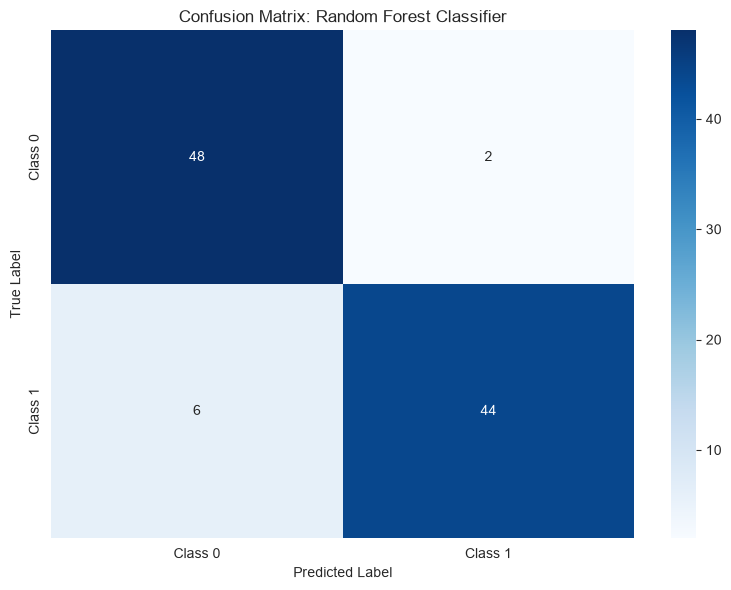


🔍 Top 5 Important Features:
  Feature 0: 0.2014
  Feature 1: 0.1867
  Feature 5: 0.1709
  Feature 7: 0.0922
  Feature 3: 0.0898


In [6]:
# Use same classification data from before
print("=" * 60)
print("RANDOM FOREST CLASSIFIER (SCIKIT-LEARN)")
print("=" * 60)

# Train model
rf_clf_sk = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf_clf_sk.fit(X_train_clf, y_train_clf)

# Predictions
y_train_pred_clf = rf_clf_sk.predict(X_train_clf)
y_test_pred_clf = rf_clf_sk.predict(X_test_clf)

# Evaluate
train_acc = accuracy_score(y_train_clf, y_train_pred_clf)
test_acc = accuracy_score(y_test_clf, y_test_pred_clf)
precision = precision_score(y_test_clf, y_test_pred_clf)
recall = recall_score(y_test_clf, y_test_pred_clf)
f1 = f1_score(y_test_clf, y_test_pred_clf)

print("\n📈 Performance:")
print(f"  Train Accuracy: {train_acc:.4f}")
print(f"  Test Accuracy:  {test_acc:.4f}")
print(f"  OOB Accuracy:   {rf_clf_sk.oob_score_:.4f}")
print(f"  Precision:      {precision:.4f}")
print(f"  Recall:         {recall:.4f}")
print(f"  F1-Score:       {f1:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test_clf, y_test_pred_clf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix: Random Forest Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Feature importance
print(f"\n🔍 Top 5 Important Features:")
top_indices = np.argsort(rf_clf_sk.feature_importances_)[::-1][:5]
for idx in top_indices:
    print(f"  Feature {idx}: {rf_clf_sk.feature_importances_[idx]:.4f}")


HOW MANY TREES? (n_estimators)

🔍 Fitting forests of different sizes...
     1 trees: test = 0.8800, OOB = 0.6225
     2 trees: test = 0.8000, OOB = 0.6925
     5 trees: test = 0.8700, OOB = 0.8275
    10 trees: test = 0.8900, OOB = 0.8625
    20 trees: test = 0.8900, OOB = 0.8900
    50 trees: test = 0.9200, OOB = 0.8950
   100 trees: test = 0.9200, OOB = 0.9000
   200 trees: test = 0.9400, OOB = 0.9175


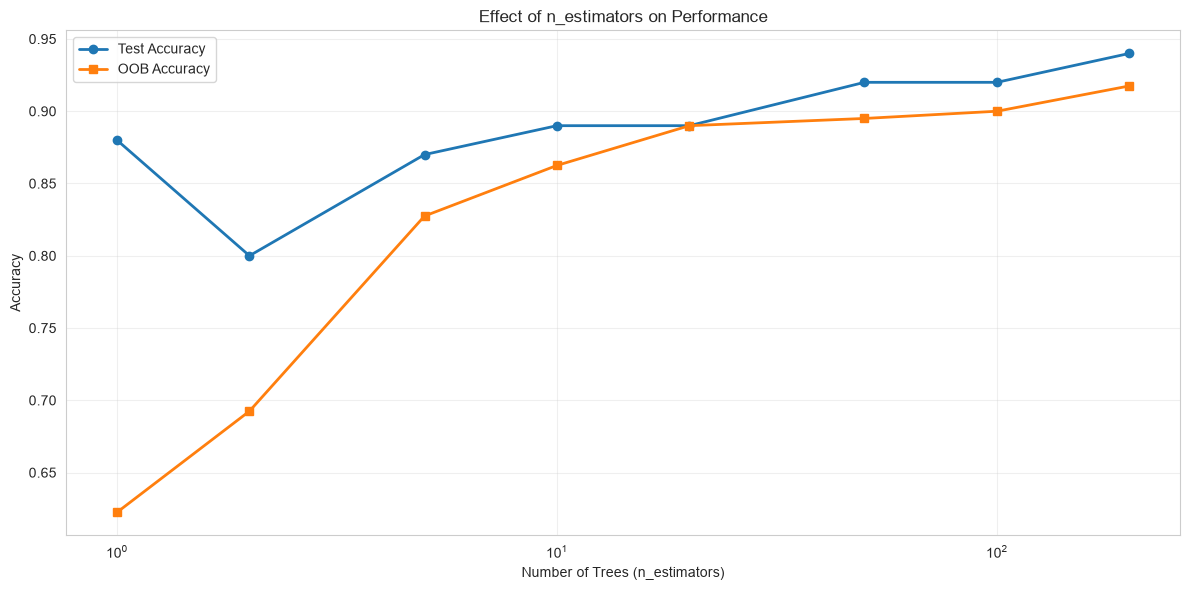

💡 Observations:
  • Both curves plateau quickly - beyond ~50 trees, accuracy barely moves
  • Adding trees never hurts accuracy; it only costs time and memory
  • OOB score tracks test accuracy closely - free validation
  • Best test accuracy: 0.9400 with 200 trees


In [7]:
# Effect of n_estimators on test accuracy and OOB score
tree_counts = [1, 2, 5, 10, 20, 50, 100, 200]
test_scores_n = []
oob_scores_n = []

print("=" * 60)
print("HOW MANY TREES? (n_estimators)")
print("=" * 60)
print("\n🔍 Fitting forests of different sizes...")

for n in tree_counts:
    rf_temp = RandomForestClassifier(
        n_estimators=n, oob_score=True, n_jobs=-1, random_state=42
    )
    rf_temp.fit(X_train_clf, y_train_clf)
    test_scores_n.append(rf_temp.score(X_test_clf, y_test_clf))
    oob_scores_n.append(rf_temp.oob_score_)
    print(f"  {n:>4} trees: test = {test_scores_n[-1]:.4f}, OOB = {oob_scores_n[-1]:.4f}")

plt.figure(figsize=(12, 6))
plt.plot(tree_counts, test_scores_n, 'o-', label='Test Accuracy', linewidth=2)
plt.plot(tree_counts, oob_scores_n, 's-', label='OOB Accuracy', linewidth=2)
plt.xscale('log')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.title('Effect of n_estimators on Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 Observations:")
print("  • Both curves plateau quickly - beyond ~50 trees, accuracy barely moves")
print("  • Adding trees never hurts accuracy; it only costs time and memory")
print("  • OOB score tracks test accuracy closely - free validation")
print(f"  • Best test accuracy: {max(test_scores_n):.4f} with {tree_counts[np.argmax(test_scores_n)]} trees")


### Regression with Scikit-learn


RANDOM FOREST REGRESSOR (SCIKIT-LEARN)

📈 Performance:
  Train R²:   0.9765
  Test R²:    0.8486
  Train RMSE: 10.05
  Test RMSE:  26.04
  Test MAE:   19.70


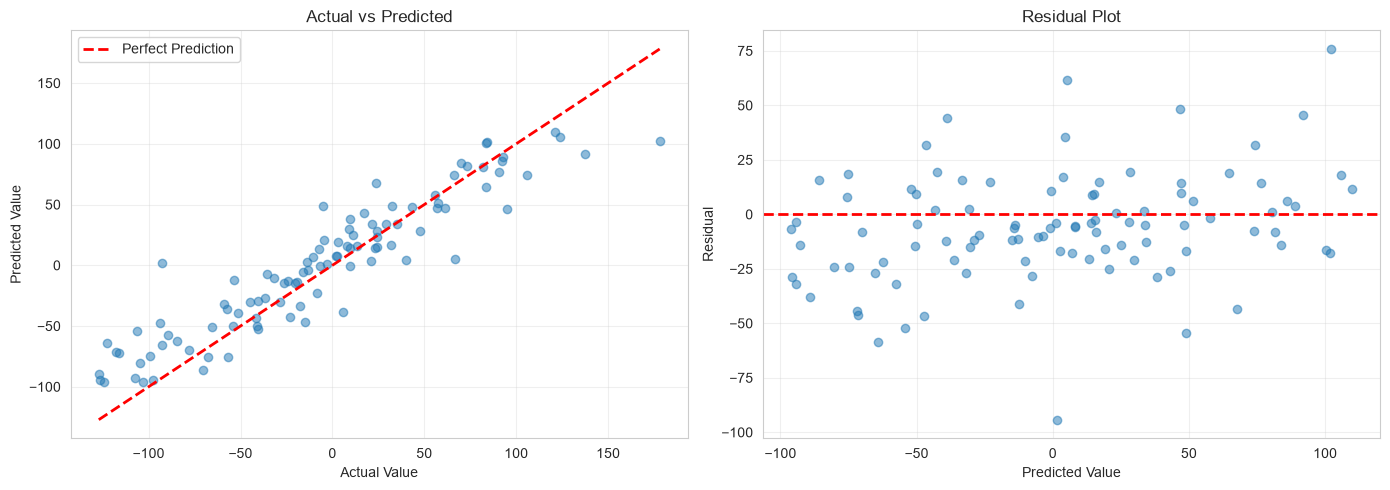


💡 The forest cancels each tree's noise-driven errors,
   so the actual-vs-predicted cloud hugs the diagonal more tightly.


In [8]:
# Use same regression data from before
print("=" * 60)
print("RANDOM FOREST REGRESSOR (SCIKIT-LEARN)")
print("=" * 60)

# Train model
rf_reg_sk = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_reg_sk.fit(X_train_reg, y_train_reg)

# Predictions
y_train_pred_reg = rf_reg_sk.predict(X_train_reg)
y_test_pred_reg = rf_reg_sk.predict(X_test_reg)

# Evaluate
train_r2 = r2_score(y_train_reg, y_train_pred_reg)
test_r2 = r2_score(y_test_reg, y_test_pred_reg)
train_rmse = np.sqrt(mean_squared_error(y_train_reg, y_train_pred_reg))
test_rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_reg))
test_mae = mean_absolute_error(y_test_reg, y_test_pred_reg)

print("\n📈 Performance:")
print(f"  Train R²:   {train_r2:.4f}")
print(f"  Test R²:    {test_r2:.4f}")
print(f"  Train RMSE: {train_rmse:.2f}")
print(f"  Test RMSE:  {test_rmse:.2f}")
print(f"  Test MAE:   {test_mae:.2f}")

# Visualize predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test_reg, y_test_pred_reg, alpha=0.5)
axes[0].plot([y_test_reg.min(), y_test_reg.max()],
             [y_test_reg.min(), y_test_reg.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Value')
axes[0].set_ylabel('Predicted Value')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_test_reg - y_test_pred_reg
axes[1].scatter(y_test_pred_reg, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Value')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 The forest cancels each tree's noise-driven errors,")
print("   so the actual-vs-predicted cloud hugs the diagonal more tightly.")


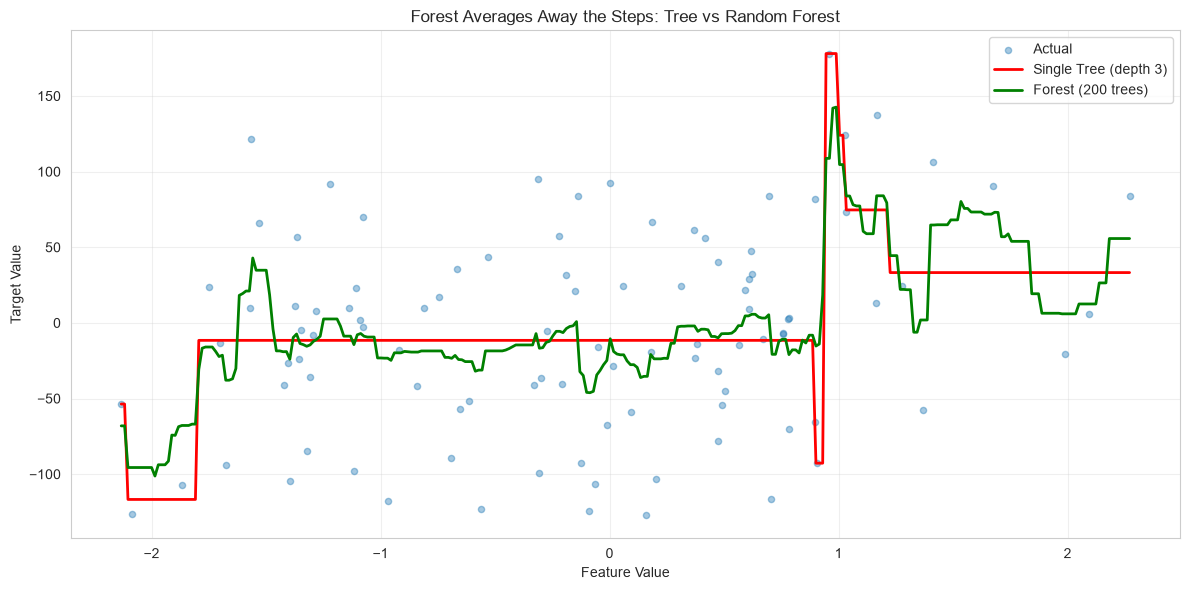

💡 Notice:
  • Single tree: a few coarse steps (piecewise constant)
  • Forest: still piecewise constant, but with many fine steps → looks smooth
  • Averaging trees with different split thresholds damps the jumps


In [9]:
# Smoothness: single tree vs forest on a single feature
# (same trick as notebook 03 - train on feature 0 only)
X_simple = X_test_reg[:, 0].reshape(-1, 1)
y_simple = y_test_reg

tree_simple = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_simple.fit(X_simple, y_simple)

forest_simple = RandomForestRegressor(
    n_estimators=200, max_depth=5, random_state=42, n_jobs=-1
)
forest_simple.fit(X_simple, y_simple)

# Predictions on a fine grid
X_grid = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
y_grid_tree = tree_simple.predict(X_grid)
y_grid_forest = forest_simple.predict(X_grid)

plt.figure(figsize=(12, 6))
plt.scatter(X_simple, y_simple, alpha=0.4, label='Actual', s=20)
plt.plot(X_grid, y_grid_tree, 'r-', linewidth=2, label='Single Tree (depth 3)')
plt.plot(X_grid, y_grid_forest, 'g-', linewidth=2, label='Forest (200 trees)')
plt.xlabel('Feature Value')
plt.ylabel('Target Value')
plt.title('Forest Averages Away the Steps: Tree vs Random Forest')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 Notice:")
print("  • Single tree: a few coarse steps (piecewise constant)")
print("  • Forest: still piecewise constant, but with many fine steps → looks smooth")
print("  • Averaging trees with different split thresholds damps the jumps")


---

## 7. Hyperparameter Tuning

Random forests are famously robust with defaults - but two hyperparameters matter: `n_estimators` (more is always safe, it only costs time) and `max_features` (the real accuracy lever).


### Classification Hyperparameter Tuning


In [10]:
# Grid Search for Classification
print("=" * 60)
print("HYPERPARAMETER TUNING - CLASSIFICATION")
print("=" * 60)

param_grid_clf = {
    'max_depth': [None, 10, 20],
    'max_features': ['sqrt', 'log2'],
    'min_samples_leaf': [1, 5]
}

grid_search_clf = GridSearchCV(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1),
    param_grid_clf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

n_combos = (len(param_grid_clf['max_depth'])
            * len(param_grid_clf['max_features'])
            * len(param_grid_clf['min_samples_leaf']))
print(f"\n🔍 Searching through {n_combos} combinations (× 5 folds)...")
print("  (n_estimators fixed at 100 - the one knob you never tune for accuracy)")

grid_search_clf.fit(X_train_clf, y_train_clf)

print("\n✅ Best Parameters:")
for param, value in grid_search_clf.best_params_.items():
    print(f"  {param}: {value}")

print(f"\n📈 Best CV Accuracy: {grid_search_clf.best_score_:.4f}")

# Test best model
best_model_clf = grid_search_clf.best_estimator_
test_score_best = best_model_clf.score(X_test_clf, y_test_clf)
print(f"Test Accuracy: {test_score_best:.4f}")


HYPERPARAMETER TUNING - CLASSIFICATION

🔍 Searching through 12 combinations (× 5 folds)...
  (n_estimators fixed at 100 - the one knob you never tune for accuracy)

✅ Best Parameters:
  max_depth: None
  max_features: sqrt
  min_samples_leaf: 1

📈 Best CV Accuracy: 0.9125
Test Accuracy: 0.9200


EFFECT OF max_features
  max_features=sqrt      : CV Accuracy = 0.9125 (+/- 0.0158)
  max_features=log2      : CV Accuracy = 0.9125 (+/- 0.0158)
  max_features=0.5       : CV Accuracy = 0.9075 (+/- 0.0127)
  max_features=None      : CV Accuracy = 0.9000 (+/- 0.0285)


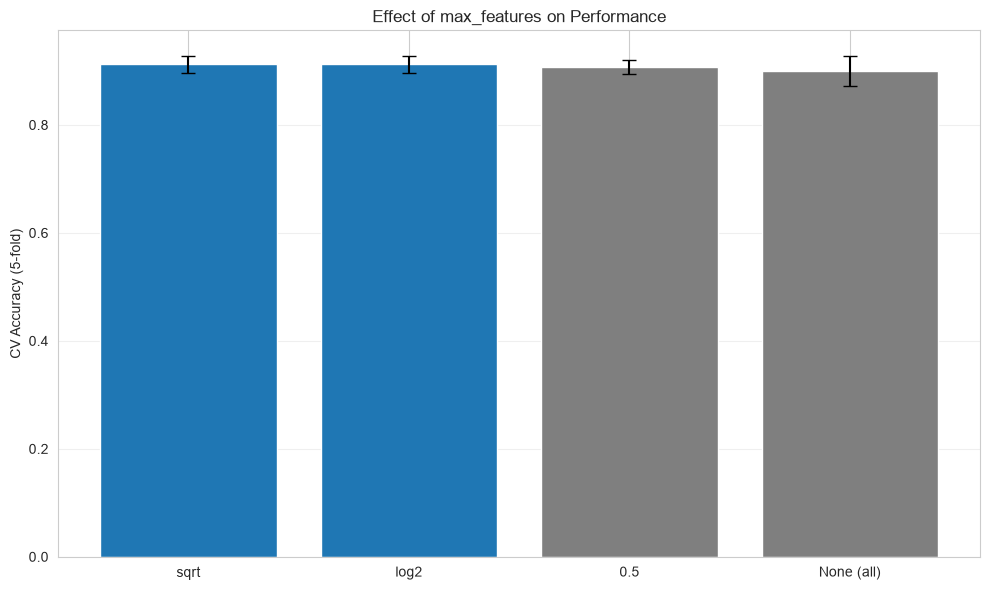

💡 Observations:
  • 'sqrt'/'log2': fewer features per node → weaker trees but lower correlation ρ
  • None (all features): stronger trees but higher ρ → less benefit from averaging
  • The sweet spot balances individual tree quality against decorrelation
  • For classification, 'sqrt' is almost always right (Breiman's original choice)


In [11]:
# Effect of max_features on accuracy (the real accuracy lever)
max_features_options = ['sqrt', 'log2', 0.5, None]
cv_means = []
cv_stds = []

print("=" * 60)
print("EFFECT OF max_features")
print("=" * 60)

for mf in max_features_options:
    rf_temp = RandomForestClassifier(
        n_estimators=100, max_features=mf, random_state=42, n_jobs=-1
    )
    scores = cross_val_score(rf_temp, X_train_clf, y_train_clf, cv=5, scoring='accuracy')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())
    label = mf if isinstance(mf, str) else str(mf)
    print(f"  max_features={label:<10}: CV Accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})")

plt.figure(figsize=(10, 6))
labels = ['sqrt', 'log2', '0.5', 'None (all)']
plt.bar(labels, cv_means, yerr=cv_stds, capsize=5,
        color=['#1f77b4', '#1f77b4', '#7f7f7f', '#7f7f7f'])
plt.ylabel('CV Accuracy (5-fold)')
plt.title('Effect of max_features on Performance')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("💡 Observations:")
print("  • 'sqrt'/'log2': fewer features per node → weaker trees but lower correlation ρ")
print("  • None (all features): stronger trees but higher ρ → less benefit from averaging")
print("  • The sweet spot balances individual tree quality against decorrelation")
print("  • For classification, 'sqrt' is almost always right (Breiman's original choice)")


### Regression Hyperparameter Tuning


In [12]:
# Grid Search for Regression
print("=" * 60)
print("HYPERPARAMETER TUNING - REGRESSION")
print("=" * 60)

param_grid_reg = {
    'max_depth': [None, 10, 20],
    'max_features': [1.0, 'sqrt'],
    'min_samples_leaf': [1, 5]
}

grid_search_reg = GridSearchCV(
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1),
    param_grid_reg,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

n_combos_reg = (len(param_grid_reg['max_depth'])
                * len(param_grid_reg['max_features'])
                * len(param_grid_reg['min_samples_leaf']))
print(f"\n🔍 Searching through {n_combos_reg} combinations (× 5 folds)...")

grid_search_reg.fit(X_train_reg, y_train_reg)

print("\n✅ Best Parameters:")
for param, value in grid_search_reg.best_params_.items():
    print(f"  {param}: {value}")

print(f"\n📈 Best CV R²: {grid_search_reg.best_score_:.4f}")

# Test best model
best_model_reg = grid_search_reg.best_estimator_
test_r2_best = best_model_reg.score(X_test_reg, y_test_reg)
print(f"Test R²: {test_r2_best:.4f}")


HYPERPARAMETER TUNING - REGRESSION

🔍 Searching through 12 combinations (× 5 folds)...

✅ Best Parameters:
  max_depth: None
  max_features: 1.0
  min_samples_leaf: 1

📈 Best CV R²: 0.8276
Test R²: 0.8486


---

## 8. Complete Hyperparameter Reference

### Random Forest Parameters

#### `n_estimators` (int, default=100) **[MOST IMPORTANT - but the easy one]**
- **Description**: Number of trees in the forest
- **Effect on Model**:
  - **More trees**: the variance term $(1-\rho)\sigma^2/B$ keeps shrinking toward 0
  - Accuracy plateaus - it never gets worse, only slower
  - Diminishing returns after ~50-200 trees on small/medium data
- **Typical Range**: [50, 100, 200, 500]
- **Tuning Strategy**:
  1. Start with 100 (scikit-learn default)
  2. Plot the OOB score against tree count to find the plateau
  3. Pick the smallest B at the plateau (faster inference, smaller model)
- **Example**: `RandomForestClassifier(n_estimators=200)`

---

#### `max_features` (str/int/float, default='sqrt' for classifier, 1.0 for regressor) **[MOST IMPORTANT - the accuracy lever]**
- **Description**: Number of features considered at each split
- **Effect on Model**:
  - **Fewer** ('log2', 'sqrt'): weaker individual trees, but lower correlation ρ → more benefit from averaging
  - **More** (None = all): stronger individual trees, but higher ρ → averaging buys less
  - This one parameter trades tree quality against decorrelation
- **Typical Range**: ['sqrt', 'log2', 0.3-0.5, None]
- **Tuning Strategy**: Start with 'sqrt' (classification) or 1.0 (regression); try 0.3-0.5 in between
- **Example**: `RandomForestClassifier(max_features='log2')`

---

#### `max_depth` (int or None, default=None)
- **Description**: Maximum depth of each tree
- **Effect**:
  - **None (default)**: trees grow to purity - fine for forests (averaging damps overfitting)
  - **Limited** (10-20): faster training/prediction, smaller model, often the same accuracy
- **Typical Range**: [10, 20, None]
- **When to limit**: large datasets, memory or latency constraints
- **Example**: `RandomForestClassifier(max_depth=20)`

---

#### `min_samples_split` (int/float, default=2)
- **Description**: Minimum samples required to split a node
- **Effect**: Larger → shallower, more regularized trees
- **Typical Range**: [2, 10, 20]
- **Example**: `RandomForestClassifier(min_samples_split=10)`

---

#### `min_samples_leaf` (int/float, default=1)
- **Description**: Minimum samples required in a leaf
- **Effect**: Larger → smoother leaf estimates, smaller trees; helps on noisy regression targets
- **Typical Range**: [1, 5, 10]
- **Example**: `RandomForestRegressor(min_samples_leaf=5)`

---

#### `bootstrap` (bool, default=True)
- **Description**: Whether each tree fits on a bootstrap sample
- **Effect**:
  - **True**: decorrelates trees via row randomness; enables OOB scoring
  - **False**: trees differ only through feature subsampling; no OOB possible
- **Keep True** unless you have a specific reason
- **Example**: `RandomForestClassifier(bootstrap=False)`

---

#### `oob_score` (bool, default=False)
- **Description**: Compute the out-of-bag score during fit
- **Effect**: A cross-validation-grade estimate, free of charge
- **When to use**: quick model checks and cheap tuning iterations
- **Example**: `RandomForestClassifier(oob_score=True)`

---

#### `criterion` (str, default='gini' for classifier)
- **Options**: 'gini', 'entropy', 'log_loss'
- **Effect**: Negligible in practice - Gini and entropy pick near-identical splits
- **Example**: `RandomForestClassifier(criterion='entropy')`

---

#### `class_weight` (dict/'balanced'/'balanced_subsample', default=None) **[Classification only]**
- **Description**: Weights applied to classes
- **'balanced_subsample'**: weights recomputed per bootstrap sample (forest-specific!)
- **When to use**: imbalanced datasets
- **Example**: `RandomForestClassifier(class_weight='balanced_subsample')`

---

#### `max_samples` (int/float, default=None)
- **Description**: Rows drawn per bootstrap sample (count or fraction)
- **Effect**: Smaller samples → faster, more diverse but weaker trees
- **When to use**: very large datasets (subsample for speed)
- **Example**: `RandomForestRegressor(max_samples=0.5)`

---

#### `n_jobs` (int, default=None)
- **Description**: Parallelism for fit and predict
- **Effect**: Trees are independent → perfect parallelism; **always use -1**
- **Example**: `RandomForestClassifier(n_jobs=-1)`

---

#### `random_state` (int, default=None)
- **Description**: Seed for bootstrap sampling and feature subsampling
- **Effect**: Reproducible bootstraps → reproducible importances and predictions
- **Always set it**
- **Example**: `RandomForestClassifier(random_state=42)`

---

### Parameter Combinations Guide

#### Solid Default (Classification):
```python
RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
```

#### Imbalanced Classification:
```python
RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced_subsample',
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
```

#### High-Dimensional Data (m > 100 features):
```python
RandomForestClassifier(
    n_estimators=300,      # more trees: each node only sees sqrt(m) features
    max_features='sqrt',
    max_depth=20,          # cap depth for a tractable forest
    random_state=42,
    n_jobs=-1
)
```

#### Regression (Noisy Targets):
```python
RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=5,    # smoother leaf estimates
    max_features=0.5,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
```

#### Fast Inference / Memory-Constrained:
```python
RandomForestClassifier(
    n_estimators=50,
    max_depth=15,
    max_samples=0.5,
    random_state=42,
    n_jobs=-1
)
```


---

## 9. Practical Tips & Common Pitfalls

### ✅ Best Practices

#### 1. **Let Trees Grow Deep**
Unlike single trees, deep forest trees are safe - averaging damps their variance.

```python
# This is fine for a forest:
rf = RandomForestClassifier(n_estimators=100)  # max_depth=None (default)

# Pruning matters for a SINGLE tree, not for a forest
```

---

#### 2. **Add Trees Until Accuracy Plateaus (Then Stop)**
```python
# Use the OOB score to find the plateau - no test set needed
for n in [50, 100, 200, 400]:
    rf = RandomForestClassifier(n_estimators=n, oob_score=True, n_jobs=-1)
    rf.fit(X_train, y_train)
    print(n, rf.oob_score_)
```

---

#### 3. **Use OOB Score for Quick Iterations**
```python
rf = RandomForestClassifier(oob_score=True, n_jobs=-1)
rf.fit(X_train, y_train)
print(f"OOB: {rf.oob_score_:.3f}")  # ≈ CV estimate, free
```

---

#### 4. **Always Set n_jobs=-1**
Trees are independent - random forests parallelize perfectly.

```python
rf = RandomForestClassifier(n_estimators=200, n_jobs=-1)
```

---

#### 5. **Check Importance Stability Across Seeds**
```python
imps = []
for seed in [0, 1, 2]:
    rf = RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=-1)
    rf.fit(X_train, y_train)
    imps.append(rf.feature_importances_)
print(np.std(imps, axis=0))  # high std → that importance is unreliable
```

---

#### 6. **Prefer Permutation Importance for Honest Rankings**
MDI importances are biased toward continuous / high-cardinality features.

```python
from sklearn.inspection import permutation_importance
result = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)
```

---

#### 7. **No Feature Scaling Needed**
Trees split on thresholds, not distances - scaling changes nothing.

```python
rf.fit(X_train, y_train)  # mixed scales are fine!
```

---

### ❌ Common Mistakes

#### 1. **Tuning n_estimators for Accuracy**
More trees plateau; they don't tune accuracy. Spend effort on `max_features`.

**Bad**:
```python
GridSearchCV(rf, {'n_estimators': [10, 50, 100, 500, 1000]})  # wasted compute
```

**Good**:
```python
GridSearchCV(rf, {'max_features': ['sqrt', 'log2', 0.3], 'min_samples_leaf': [1, 5]})
```

---

#### 2. **Using a Random Forest for Extrapolation**
**Bad**:
```python
# Trained on ages 20-60; age 80 clamps to the last leaf's value
rf_reg.predict([[80]])
```

**Good**:
```python
LinearRegression().fit(X_train, y_train)  # linear models extrapolate
```

---

#### 3. **Trusting MDI Importances on Mixed Feature Types**
**Bad**:
```python
# Continuous features get systematically higher importances
rf.feature_importances_  # biased
```

**Good**:
```python
permutation_importance(rf, X_test, y_test)  # model-agnostic, unbiased
```

---

#### 4. **Expecting Forests to Fix a Bad Model Class**
Forests reduce **variance**, not **bias**.

**Bad**:
```python
# 1000 trees can't learn a linear law better than 1 tree can
rf = RandomForestRegressor(n_estimators=1000)
```

**Good**:
```python
# If the relationship is truly linear - use the linear model!
```

---

#### 5. **Forgetting random_state**
Bootstraps and feature draws are random - without a seed, results wobble between runs.

```python
rf = RandomForestClassifier(random_state=42)  # reproducible
```

---

#### 6. **Using Raw Vote Fractions as Calibrated Probabilities**
Vote fractions are coarse; don't use them for risk scoring without calibration.

```python
from sklearn.calibration import CalibratedClassifierCV
calibrated = CalibratedClassifierCV(rf, method='isotonic')
calibrated.fit(X_train, y_train)
```

---

### Performance Optimization

#### Computational Complexity
- **Training**: O(B × n × m_selected × log n) total - but **perfectly parallel** (`n_jobs=-1`)
- **Prediction**: O(B × depth) per sample - 100 trees = 100 root-to-leaf walks
- **Memory**: O(B × nodes) - forests are heavy; cap depth or `max_leaf_nodes` at the edge

#### For Large Datasets
```python
rf = RandomForestClassifier(
    n_estimators=100,
    max_samples=0.3,     # each tree sees 30% of rows → ~3x faster
    max_depth=20,
    n_jobs=-1
)
```

---

### Debugging Tips

#### Forest Worse Than a Single Tree?
1. **Too few trees** - with 5-10 trees the vote still wobbles
2. **max_features too generous** - 'sqrt' on a handful of features ≈ all features (no decorrelation)
3. **Unrepresentative test split** - compare against the OOB score to check

#### OOB Score Much Higher Than Test Score?
1. **Distribution shift** between train and test
2. **Leakage** from features correlated with row order (bootstraps reuse rows)

#### Importances Look Wrong?
1. **Cardinality bias** - continuous features outrank binary ones under MDI
2. **Correlated features** - importance splits between them
3. **Second opinion** - run `permutation_importance`


---

## 10. Real-world Examples

### Example 1: Customer Churn Prediction (Classification)


In [13]:
# Simulate customer churn dataset (same simulation as notebook 03
# - so the tree vs forest comparison is a fair fight)
np.random.seed(42)

n_customers = 1000
age = np.random.randint(18, 70, n_customers)
tenure = np.random.randint(0, 120, n_customers)  # months
monthly_charges = np.random.uniform(20, 120, n_customers)
total_charges = monthly_charges * tenure + np.random.normal(0, 100, n_customers)
contract_type = np.random.choice([0, 1, 2], n_customers)  # 0: month-to-month, 1: 1-year, 2: 2-year
num_services = np.random.randint(0, 6, n_customers)

# Create churn based on features (synthetic logic)
churn_prob = (
    0.3  # base probability
    - 0.003 * age  # older customers less likely to churn
    - 0.004 * tenure  # longer tenure = less churn
    + 0.002 * monthly_charges  # higher charges = more churn
    - 0.1 * contract_type  # longer contracts = less churn
    - 0.05 * num_services  # more services = less churn
    + np.random.normal(0, 0.1, n_customers)  # random noise
)
churn = (churn_prob > 0.3).astype(int)

X_churn = np.column_stack([age, tenure, monthly_charges, total_charges, contract_type, num_services])
feature_names_churn = ['Age', 'Tenure (months)', 'Monthly Charges', 'Total Charges', 'Contract Type', 'Num Services']

# Split data
X_train_churn, X_test_churn, y_train_churn, y_test_churn = train_test_split(
    X_churn, churn, test_size=0.3, random_state=42, stratify=churn
)

print("=" * 60)
print("REAL-WORLD EXAMPLE: CUSTOMER CHURN PREDICTION")
print("=" * 60)
print(f"\n📊 Dataset:")
print(f"  Total customers: {n_customers}")
print(f"  Training: {len(X_train_churn)}")
print(f"  Test: {len(X_test_churn)}")
print(f"  Features: {', '.join(feature_names_churn)}")

print(f"\n⚖️ Churn Distribution:")
churn_counts = np.bincount(churn)
print(f"  Retained (0): {churn_counts[0]} ({churn_counts[0]/len(churn):.1%})")
print(f"  Churned (1): {churn_counts[1]} ({churn_counts[1]/len(churn):.1%})")

print("\n💡 Same data-generating process as notebook 03's example:")
print("   any difference you see below is purely the ensemble effect.")


REAL-WORLD EXAMPLE: CUSTOMER CHURN PREDICTION

📊 Dataset:
  Total customers: 1000
  Training: 700
  Test: 300
  Features: Age, Tenure (months), Monthly Charges, Total Charges, Contract Type, Num Services

⚖️ Churn Distribution:
  Retained (0): 982 (98.2%)
  Churned (1): 18 (1.8%)

💡 Same data-generating process as notebook 03's example:
   any difference you see below is purely the ensemble effect.


RANDOM FOREST vs SINGLE TREE: CUSTOMER CHURN

              Model  Train Acc  Test Acc  Precision  Recall       F1
Single Tree (nb 03)   0.931429  0.953333   0.153846     0.4 0.222222
      Random Forest   0.998571  0.986667   1.000000     0.2 0.333333


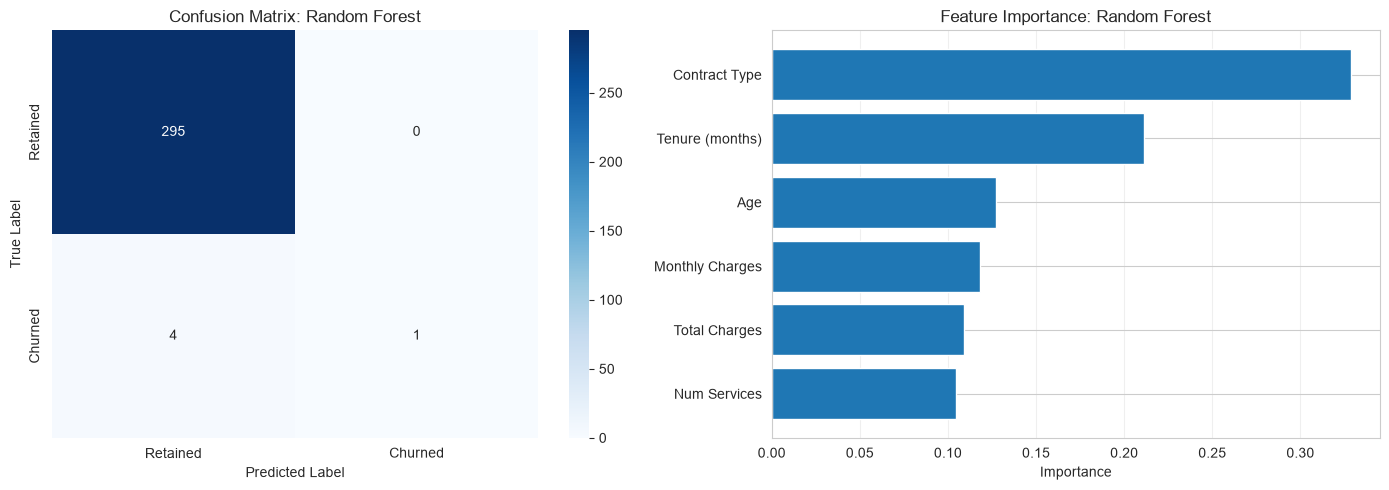


🔍 Top Churn Predictors (forest):
  • Contract Type: 0.3287
  • Tenure (months): 0.2115
  • Age: 0.1274

💡 What the forest buys you on the same data:
  • Higher test metrics than the single tree
  • A much smaller train/test gap than an unpruned tree would show
  • Importances averaged over 200 trees - far more stable


In [14]:
# Train a random forest - and compare directly against notebook 03's single tree
print("=" * 60)
print("RANDOM FOREST vs SINGLE TREE: CUSTOMER CHURN")
print("=" * 60)

# Single tree (exact configuration from notebook 03)
tree_churn = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)
tree_churn.fit(X_train_churn, y_train_churn)

# Random forest
rf_churn = RandomForestClassifier(
    n_estimators=200,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_churn.fit(X_train_churn, y_train_churn)

# Side-by-side evaluation
models_churn = {
    'Single Tree (nb 03)': tree_churn,
    'Random Forest': rf_churn
}

results_churn = []
for name, model in models_churn.items():
    y_pred = model.predict(X_test_churn)
    results_churn.append({
        'Model': name,
        'Train Acc': model.score(X_train_churn, y_train_churn),
        'Test Acc': model.score(X_test_churn, y_test_churn),
        'Precision': precision_score(y_test_churn, y_pred),
        'Recall': recall_score(y_test_churn, y_pred),
        'F1': f1_score(y_test_churn, y_pred)
    })

df_churn = pd.DataFrame(results_churn)
print("\n" + df_churn.to_string(index=False))

# Confusion matrix + importances for the forest
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_rf = confusion_matrix(y_test_churn, rf_churn.predict(X_test_churn))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'], ax=axes[0])
axes[0].set_title('Confusion Matrix: Random Forest')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

importance_rf = pd.DataFrame({
    'Feature': feature_names_churn,
    'Importance': rf_churn.feature_importances_
}).sort_values('Importance', ascending=False)
axes[1].barh(importance_rf['Feature'], importance_rf['Importance'])
axes[1].set_xlabel('Importance')
axes[1].set_title('Feature Importance: Random Forest')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n🔍 Top Churn Predictors (forest):")
for idx, row in importance_rf.head(3).iterrows():
    print(f"  • {row['Feature']}: {row['Importance']:.4f}")

print("\n💡 What the forest buys you on the same data:")
print("  • Higher test metrics than the single tree")
print("  • A much smaller train/test gap than an unpruned tree would show")
print("  • Importances averaged over 200 trees - far more stable")


### Example 2: House Price Prediction (Regression)


In [15]:
# Simulate house price dataset (same simulation as notebook 03)
np.random.seed(42)

n_houses = 500
sqft = np.random.randint(800, 4000, n_houses)
bedrooms = np.random.randint(1, 6, n_houses)
bathrooms = np.random.randint(1, 4, n_houses)
age = np.random.randint(0, 50, n_houses)
garage = np.random.randint(0, 3, n_houses)
location_score = np.random.uniform(1, 10, n_houses)  # 1=bad, 10=excellent

# Create price based on features
price = (
    100  # base price in $1000s
    + 0.15 * sqft  # $150 per sqft
    + 20 * bedrooms
    + 15 * bathrooms
    - 2 * age  # depreciation
    + 10 * garage
    + 30 * location_score
    + np.random.normal(0, 30, n_houses)  # noise
)

X_house = np.column_stack([sqft, bedrooms, bathrooms, age, garage, location_score])
feature_names_house = ['Sqft', 'Bedrooms', 'Bathrooms', 'Age', 'Garage', 'Location Score']

# Split data
X_train_house, X_test_house, y_train_house, y_test_house = train_test_split(
    X_house, price, test_size=0.3, random_state=42
)

print("=" * 60)
print("REAL-WORLD EXAMPLE: HOUSE PRICE PREDICTION")
print("=" * 60)
print(f"\n📊 Dataset:")
print(f"  Total houses: {n_houses}")
print(f"  Training: {len(X_train_house)}")
print(f"  Test: {len(X_test_house)}")
print(f"  Features: {', '.join(feature_names_house)}")
print(f"\n💰 Price Range:")
print(f"  Min: ${price.min():.0f}k")
print(f"  Max: ${price.max():.0f}k")
print(f"  Mean: ${price.mean():.0f}k")
print(f"  Median: ${np.median(price):.0f}k")


REAL-WORLD EXAMPLE: HOUSE PRICE PREDICTION

📊 Dataset:
  Total houses: 500
  Training: 350
  Test: 150
  Features: Sqft, Bedrooms, Bathrooms, Age, Garage, Location Score

💰 Price Range:
  Min: $264k
  Max: $1097k
  Mean: $680k
  Median: $667k


              Model       R²      RMSE       MAE
Single Tree (nb 03) 0.861542 59.519999 47.845088
      Random Forest 0.934277 41.007412 33.691176


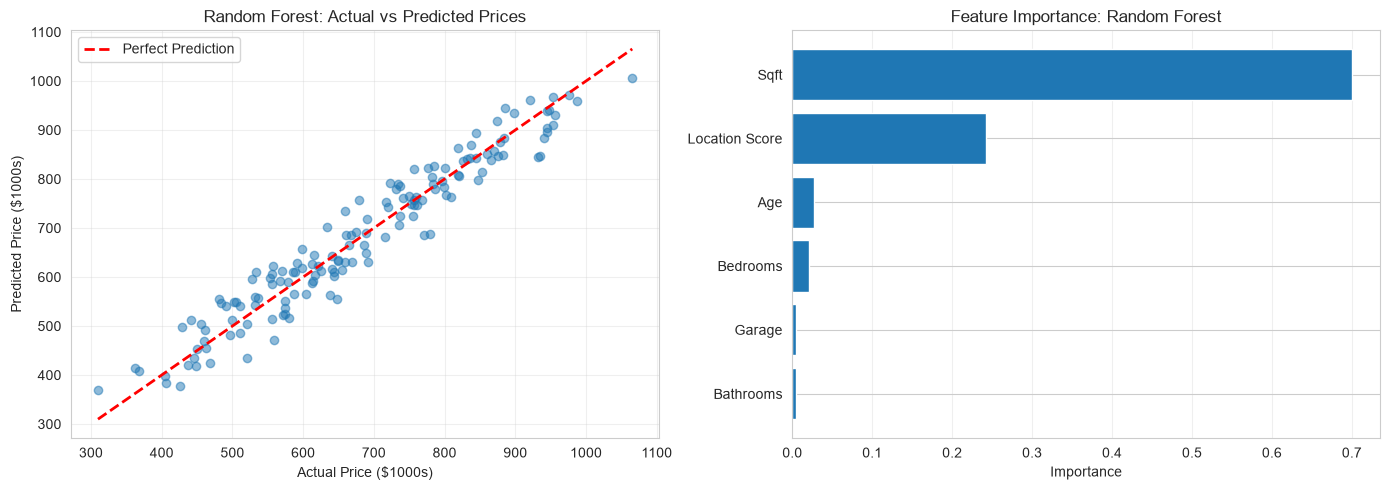


🔍 Top Price Predictors (forest):
  • Sqft: 0.7001
  • Location Score: 0.2423
  • Age: 0.0268

💡 The RMSE drops because averaging cancels each tree's
   noise-driven split mistakes - variance reduction in action.


In [16]:
# Train a random forest regressor - and compare against notebook 03's tree
tree_house = DecisionTreeRegressor(
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
tree_house.fit(X_train_house, y_train_house)

rf_house = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_house.fit(X_train_house, y_train_house)

# Side-by-side evaluation
y_pred_tree_house = tree_house.predict(X_test_house)
y_pred_rf_house = rf_house.predict(X_test_house)

results_house = pd.DataFrame([
    {
        'Model': 'Single Tree (nb 03)',
        'R²': r2_score(y_test_house, y_pred_tree_house),
        'RMSE': np.sqrt(mean_squared_error(y_test_house, y_pred_tree_house)),
        'MAE': mean_absolute_error(y_test_house, y_pred_tree_house)
    },
    {
        'Model': 'Random Forest',
        'R²': r2_score(y_test_house, y_pred_rf_house),
        'RMSE': np.sqrt(mean_squared_error(y_test_house, y_pred_rf_house)),
        'MAE': mean_absolute_error(y_test_house, y_pred_rf_house)
    }
])
print(results_house.to_string(index=False))

# Visualize predictions + importances
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_house, y_pred_rf_house, alpha=0.5)
axes[0].plot([y_test_house.min(), y_test_house.max()],
             [y_test_house.min(), y_test_house.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($1000s)')
axes[0].set_ylabel('Predicted Price ($1000s)')
axes[0].set_title('Random Forest: Actual vs Predicted Prices')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

importance_house = pd.DataFrame({
    'Feature': feature_names_house,
    'Importance': rf_house.feature_importances_
}).sort_values('Importance', ascending=False)
axes[1].barh(importance_house['Feature'], importance_house['Importance'])
axes[1].set_xlabel('Importance')
axes[1].set_title('Feature Importance: Random Forest')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n🔍 Top Price Predictors (forest):")
for idx, row in importance_house.head(3).iterrows():
    print(f"  • {row['Feature']}: {row['Importance']:.4f}")

print("\n💡 The RMSE drops because averaging cancels each tree's")
print("   noise-driven split mistakes - variance reduction in action.")


---

## 11. Comparison with Other Algorithms

### When to Choose Random Forest vs Alternatives

| Aspect | Random Forest | Decision Trees | Linear Models | Gradient Boosting | KNN |
|--------|--------------|----------------|---------------|-------------------|-----|
| **Interpretability** | ⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐ | ⭐ |
| **Default Accuracy** | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ |
| **Training Speed** | ⭐⭐⭐⭐ (parallel) | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐ (sequential) | ⭐⭐⭐⭐⭐ |
| **Prediction Speed** | ⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐ |
| **Non-linear** | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ |
| **Feature Scaling** | Not needed | Not needed | Required | Not needed | Required |
| **Overfitting Risk** | Low | High | Low | Medium-High | Medium |
| **Tuning Burden** | Low | High | Low | High | Low |
| **Extrapolation** | ❌ No | ❌ No | ✅ Yes | ❌ No | ❌ No |
| **OOB Validation** | ✅ Free | ❌ | ❌ | ❌ | ❌ |
| **Parallel Training** | ✅ Perfect | N/A | ✅ | ❌ Sequential | N/A |
| **Mixed Features** | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐ |

### Practical Comparison


In [17]:
# Compare algorithms on the same classification task
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
import time

print("=" * 60)
print("ALGORITHM COMPARISON - CLASSIFICATION")
print("=" * 60)

classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(max_depth=7, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': GaussianNB()
}

results_comp = []

for name, clf in classifiers.items():
    # Time training
    start = time.time()
    clf.fit(X_train_clf, y_train_clf)
    train_time = time.time() - start

    # Time prediction
    start = time.time()
    y_pred = clf.predict(X_test_clf)
    pred_time = time.time() - start

    # Metrics
    acc = accuracy_score(y_test_clf, y_pred)

    results_comp.append({
        'Algorithm': name,
        'Accuracy': acc,
        'Train Time (s)': train_time,
        'Pred Time (ms)': pred_time * 1000
    })

# Display results
df_comp = pd.DataFrame(results_comp)
print("\n" + df_comp.to_string(index=False))

print("\n" + "=" * 60)
print("💡 Key Insights:")
print("=" * 60)
print("✓ Random Forest:")
print("  • Usually the best accuracy with zero tuning")
print("  • Training parallelizes across cores (n_jobs=-1)")
print("  • Prediction costs B tree traversals")
print("\n✓ Decision Tree:")
print("  • Fastest and most interpretable, but least stable")
print("\n✓ Logistic Regression:")
print("  • Fast and simple; best for linear relationships")
print("\n✓ Naive Bayes:")
print("  • Very fast; assumes feature independence")


ALGORITHM COMPARISON - CLASSIFICATION

          Algorithm  Accuracy  Train Time (s)  Pred Time (ms)
      Random Forest      0.92        0.127052       27.231693
      Decision Tree      0.87        0.001901        0.184298
Logistic Regression      0.82        0.002856        0.165462
        Naive Bayes      0.85        0.000618        0.135422

💡 Key Insights:
✓ Random Forest:
  • Usually the best accuracy with zero tuning
  • Training parallelizes across cores (n_jobs=-1)
  • Prediction costs B tree traversals

✓ Decision Tree:
  • Fastest and most interpretable, but least stable

✓ Logistic Regression:
  • Fast and simple; best for linear relationships

✓ Naive Bayes:
  • Very fast; assumes feature independence


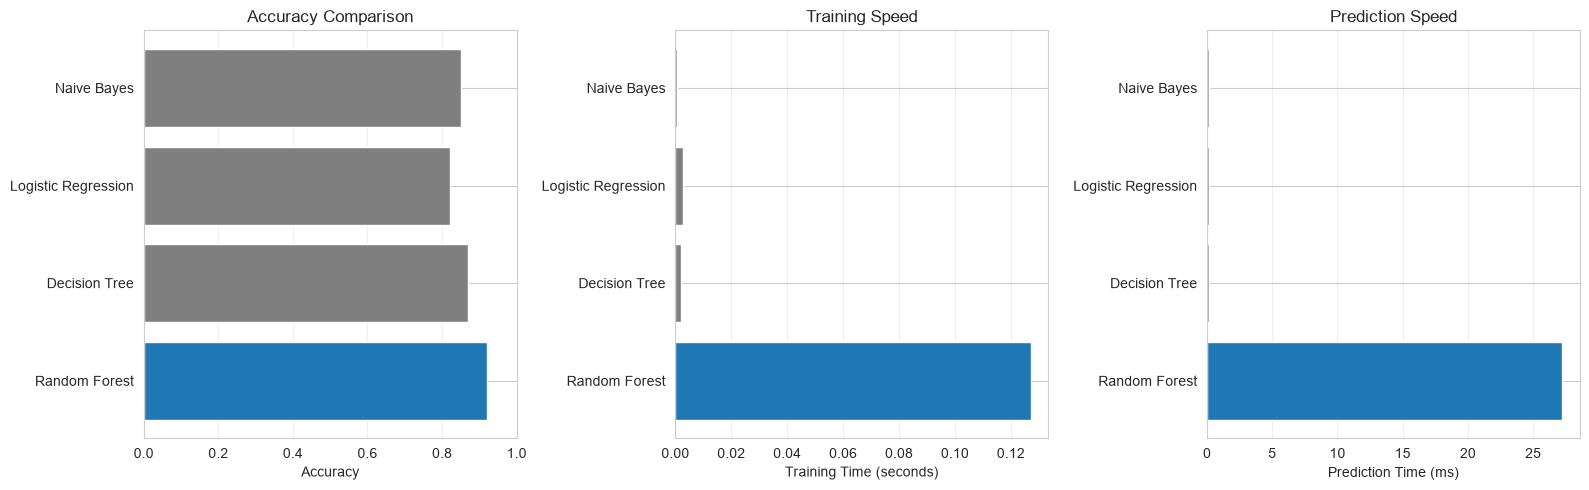


⚠️ The Random Forest tradeoff in one picture:
  • Best accuracy (0.9200) - but slower training than a single tree
  • The training cost is parallelized away with n_jobs=-1
  • Prediction cost scales with tree count - prune n_estimators at the plateau


In [18]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

algorithms = df_comp['Algorithm']
accuracies = df_comp['Accuracy']
train_times = df_comp['Train Time (s)']
pred_times = df_comp['Pred Time (ms)']

colors = ['#1f77b4' if 'Random' in alg else '#7f7f7f' for alg in algorithms]

# Accuracy comparison
axes[0].barh(algorithms, accuracies, color=colors)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Accuracy Comparison')
axes[0].set_xlim([0, 1])
axes[0].grid(True, alpha=0.3, axis='x')

# Training time
axes[1].barh(algorithms, train_times, color=colors)
axes[1].set_xlabel('Training Time (seconds)')
axes[1].set_title('Training Speed')
axes[1].grid(True, alpha=0.3, axis='x')

# Prediction time
axes[2].barh(algorithms, pred_times, color=colors)
axes[2].set_xlabel('Prediction Time (ms)')
axes[2].set_title('Prediction Speed')
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n⚠️ The Random Forest tradeoff in one picture:")
print(f"  • Best accuracy ({accuracies.iloc[0]:.4f}) - but slower training than a single tree")
print("  • The training cost is parallelized away with n_jobs=-1")
print("  • Prediction cost scales with tree count - prune n_estimators at the plateau")


---

## 12. References

### 📚 Academic Papers & Books

1. **Original Work**:
   - Breiman, L. (2001). "Random Forests", *Machine Learning*, 45(1), 5-32
   - Breiman, L. (1996). "Bagging Predictors", *Machine Learning*, 24(2), 123-140
   - Ho, T. K. (1995). "Random Decision Forests" - the random subspace method
   - Amit, Y., & Geman, D. (1997). "Shape Quantization and Recognition with Randomized Trees"

2. **Modern Textbooks**:
   - Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (Chapter 15)
   - James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). *An Introduction to Statistical Learning* (Chapter 8.2)

3. **Understanding Importances**:
   - Louppe, G. (2014). *Understanding Random Forests* (PhD thesis)
   - Strobl, C. et al. (2007). "Bias in Random Forest Variable Importance Measures"

### 🌐 Online Resources

- [Scikit-learn: Forests of Randomized Trees](https://scikit-learn.org/stable/modules/ensemble.html#forests-of-randomized-trees)
- [StatQuest: Random Forests](https://www.youtube.com/watch?v=J4Wdy0Wc_xQ)
- [StatQuest: Bagging and OOB](https://www.youtube.com/watch?v=sQ8PqwNtdBU)
- [Scikit-learn: Permutation Importance](https://scikit-learn.org/stable/modules/permutation_importance.html)

### 📊 Key Concepts to Master

- **Bagging**: bootstrap sampling + aggregation
- **Bootstrap statistics**: ~63.2% unique rows, ~36.8% out-of-bag per tree
- **Decorrelation**: `max_features` lowers ρ in Var = ρσ² + (1-ρ)/B·σ²
- **OOB error**: cross-validation-grade estimate, free during training
- **Feature importance**: MDI (fast, biased) vs permutation (unbiased)
- **The two levers**: `n_estimators` (never hurts) vs `max_features` (the real accuracy knob)

### 🔗 Related Notebooks in this Repository

- `03_decision_trees.ipynb` - the base learner this forest is built on
- `08_gradient_boosting.ipynb` - the *other* tree ensemble (sequential, not parallel)
- `09_xgboost.ipynb` / `10_lightgbm.ipynb` / `11_catboost.ipynb` - production boosting libraries
- `16_ensemble_methods.ipynb` - voting/stacking across model families

### 📈 Evaluation Metrics

**For Classification:**
- Accuracy, Precision, Recall, F1-Score
- Confusion Matrix
- OOB Accuracy (free validation)
- ROC-AUC (on vote-fraction probabilities)

**For Regression:**
- R², RMSE, MAE
- OOB R² (free validation)
- Residual plots

---

## Summary & Key Takeaways

### What We Learned

1. **Theory**: RF = bagging + per-node random feature subsampling + aggregation
2. **Math**: Var(average) = ρσ² + (1-ρ)/B·σ² - averaging fixes variance, subsampling fixes correlation
3. **Assumptions**: Almost none - no scaling, no distribution, no linearity requirements
4. **Implementation**: Built the forest from scratch on top of our scratch decision trees
5. **Hyperparameters**: `n_estimators` is the easy knob (more is safe), `max_features` is the real one
6. **Tuning**: OOB gives free validation; grid-search `max_features`/`min_samples_leaf`
7. **Practice**: On the same churn and house data as notebook 03, the forest beat the single tree

### When to Use Random Forest

✅ **Use when**:
- Tabular data and you need a strong model with minimal tuning
- Non-linear relationships and interactions
- Robustness to outliers, noise, and mixed feature scales
- Feature importance analysis
- You want free honest validation (OOB)

❌ **Avoid when**:
- Extrapolation beyond the training range is required
- Full decision interpretability is required
- Data is very high-dimensional and sparse (text)
- Extreme latency or memory budgets

### Key Differences: Classification vs Regression

| Aspect | RF Classification | RF Regression |
|--------|-------------------|---------------|
| **Aggregation** | Majority vote | Mean of predictions |
| **max_features default** | 'sqrt' | 1.0 (all features) |
| **Probabilities** | Vote fractions | N/A |
| **OOB score** | Accuracy | R² |

### Best Practices Checklist

- ✅ Start with defaults + `n_jobs=-1` + `random_state`
- ✅ Use OOB score for quick validation
- ✅ Add trees until the OOB curve plateaus
- ✅ Tune `max_features` and `min_samples_leaf`, not `n_estimators`
- ✅ No feature scaling needed
- ✅ Use `class_weight='balanced_subsample'` for imbalanced data
- ✅ Verify importances with permutation importance
- ✅ Remember: no extrapolation, ever

### Advantages vs Disadvantages

**Advantages:**
- ✅ Excellent default accuracy on tabular data
- ✅ Minimal tuning burden
- ✅ No feature scaling or distribution assumptions
- ✅ Robust to outliers and noise
- ✅ Built-in feature importances + OOB validation
- ✅ Perfectly parallel training
- ✅ Stable predictions and importances

**Disadvantages:**
- ❌ Cannot extrapolate
- ❌ Far less interpretable than a single tree
- ❌ Heavy memory footprint (B full trees)
- ❌ Slower prediction than single models (B traversals)
- ❌ MDI importances biased toward continuous features
- ❌ Poor on very high-dimensional sparse data
- ❌ Not incremental (streaming data needs refits)

### Next Steps

1. **Compare** with gradient boosting (`08`) - the sequential counterpart
2. **Try** permutation importance on your own data
3. **Tune** `max_features` on a high-dimensional problem
4. **Watch** the OOB curve to understand the plateau
5. **Explore** the boosting libraries (`09`-`11`) - where tree ensembles went industrial
6. **Read** Breiman (2001) - short, readable, and the source of everything above

---

**Congratulations!** You now have a comprehensive understanding of Random Forests for both classification and regression! 🌲🎉

**Remember**: more trees never hurt accuracy - they only cost time. Spend your tuning budget on `max_features`.
